## **Selección de Extractores de Características (Backbones)**

En este notebook, llevamos a cabo el entrenamiento y evaluación (en validación) de los modelos resultantes de las distintas combinaciones de los codificadores unimodales tras aplicar *Early Fusion* (**concatenación a nivel de características**), que es la estrategia base que hemos elegido apoyándonos en la literatura multimodal. Este mecanismo establece que, tras proyectar los vectores de características en un espacio latente común (labor llevada a cabo por nuestros adaptadores), resultando en vectores de 512 dimensiones por cada modalidad con media 0 y desviación típica 1, estos se concatenan directamente resultado en un vector de características global por cada muestra de **1536 dimensiones** (512*3). Este vector será la entrada del posterior clasificador. Es la estrategia más sencilla de fusión.

El Grid Search se compone de un total de **18 configuraciones distintas** (18 modelos a entrenar y evaluar). El objetivo es identificar los **backbones óptimos** que mayor rendimiento conjunto obtienen, analizando los resultados obtenidos y comparándolos con el poder predictivo aislado de los baselines unimodales obtenidos en el notebook anterior. 

El entrenamiento se lleva a cabo con hiperparámetros fijados derivados de la literatura y del EDA realizado sobre el corpus global. 
Estos hiperparámetros seleccionados son **exactamente los mismos** (excepto `hidden_mlp`) que hemos establecido para los baselines unimodales, cumpliendo así con el rigor metodológico y permitiendo la comparación justa. 

Las métricas a comparar son las seleccionadas para todo nuestro proyecto (principalmente, **F1-Score Macro**, **Recall** y **ROC-AUC**, entre otras).

Al final de este notebook se encuentra la elección del mejor **codificador base** para cada modalidad, el cual se fijará para las posteriores arquitecturas multimodales. 

**El notebook se estructura de la siguiente manera:**
1. **Entrenamiento y Evaluación (en Validación) de las arquitecturas *Early-Fusion***: Utilizando los *scripts* `.py` donde se definen las estrategias de fusión, aplicamos *Early-Fusion* para la concatenación de los *embeddings* extraídos por los codificadores base de cada modalidad. Entrenamos la arquitectura resultante (adaptador + early fusion + Clasificador MLP) fijando los hiperparámetros. Este proceso lo repetimos por cada una de las combinaciones de los **backbones** sobre el corpus global unificado. Al finalizar el entrenamiento de cada modelo, se muestran los resultados obtenidos en la evaluación con la partición de validación del dataset global unificado. Mostramos las métricas fijadas previamente (ya mencionadas).

2. **Comparación con *baseline* unimodal**: Comparamos los resultados en grupos por cada codificador (por ejemplo, el baseline unimodal de ResNet se comparará con aquellas arquitecturas multimodales que lo presenten).

3. **Elección de los backbones óptimos**: Finalmente, en base al análisis realizado, se seleccionan los **backbones** que consiguen el mayor rendimiento conjunto. 

In [1]:
# Carga de las librerías:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### **1. Entrenamiento y Evaluación (en Validación) de las arquitecturas *Early-Fusion***:

Para realizar una comparación justa con los *baselines* unimodales, fijamos los mismos hiperparámetros utilizados para estos, extraídos de la literatura y EDA (en este último caso, para las ventanas). Estos hiperparámetros son:

* **Configuración de la arquitectura**: Los mismos a los baselines unimodales (excepto por `hidden_mlp`). Valores fijados teniendo en cuenta los valores respaldados por la literatura y las dimensiones de los vectores de entrada.

    * `proj_dim`= 512 (valor predeterminado). Las dimensiones del espacio latente común de las modalidades será de 512.
    * `hidden_mlp`= 512 (**valor fijado**). Este valor indica las dimensiones del espacio latente proyectado por la primera capa del Clasificador MLP tras aplicar la estrategia de fusión, para comprimir las características iniciales recibidas. **Este valor es el único distinto a los baselines unimodales**.
    * `hidden_lstm`= 512 (valor predeterminado).  Este valor indica las dimensiones del vector resultante obtenido de la última capa oculta de la LSTM. 
    * `lstm_layers`= 1 (valor predeterminado). La LSTM de los adaptadores contará con 1 única capa.

* **Entrenamiento y Regularización**: Parámetros fijados de acuerdo a la literatura.

    * `lr` (**Learning Rate**)= 1e-4 (valor predeterminado)
    * `dropout`= 0.5 (valor predeterminado)
    * `weight_decay`= 1e-2 (valor predeterminado)
    * `epochs`= 20 (valor predeterminado)
    * `patience`= 5 (valor predeterminado)
    * `pos_weight_mult`= 1.0 (valor predeterminado). Este valor es el multiplicador para el peso de la clase positiva, a mayor valor hacemos que el modelo reciba mayor penalización cuando falla en la clase positiva (estrés).

* **Gestión del Desbalanceo**:

    * `BCEWithLogitsLoss` + `pos_weight`: Fijamos`pos_weight` como el ratio entre el número de muestras negativas y positivas (**num_negativos/num_positivos**) fijado en train.

* **Regularización y Optimizador**:

    * `AdamW` con `weight_decay=1e-2`

* **Ciclo de Entrenamiento**: 
    * **Epochs** `20` y **Batch Size** `32`.
    * **Early Stopping (Paciencia = 5)**.

* **Tamaño Ventanas**: Parámetros fijados de acuerdo al EDA realizado.
    * **Vídeo: 32 frames**.
    * **Audio: 11 segundos**.
    * **Texto: 64 tokens**.


En cuanto a la arquitectura, se mantiene la mayor parte de ella exactamente igual a los *baselines* unimodales: 

* **Adaptadores**: Los mismos empleados para los *baselines* unimodales por cada modalidad--> `VisualAdapter`, `AudioAdapter`, `TextAdapter` importados desde `models.adapters` (`adapters.py`).

* **Clasificador**: 
    * **Estrategia de Fusión**: Al aplicar *early fusion*, la entrada al clasificador es de un vector de 1536 (512 x 3) dimensiones, por cada una de las muestras del batch. Por tanto, lo **único** que cambia con respecto al clasificador de los baselines *unimodales* es que **añadimos una primera capa adicional** para proyectar esas **1536 dimensiones** a **512 dimensiones**. Al añadir la capa `nn.Linear(1536, 512)`, estamos comprimiendo la información combinada de vuelta a un tamaño de 512. A partir de ahí, la red hace exactamente el mismo camino que la unimodal: 512 -> 128 -> 1. **Esto permite la comparación justa para identificar qué codificadores son los que mayor rendimiento conjunto obtienen**. Debido a esto, en los baselines unimodales `hidden_mlp` la hemos fijado como **128** mientras que para esta *Early Fusion* se ha fijado a **512**. Se muestra en la figura siguiente la diferencia entre ambos clasificadores: 

    <img src="../figuras/Fig_Comparacion_Clasificador_Unimodal_EarlyFusion_notebook.png" width="1000">

A continuación, vamos entrenando cada una de las arquitecturas multimodales *early fusion* sobre el dataset global unificado (ya que el propósito de esta sección es seleccionar los codificadores):

* `ResNet` + `Wav2Vec` + `BERT`:

**Entrenamiento:**

In [3]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|███████████████████| 448/448 [00:26<00:00, 16.68it/s, loss=1.3]
Epoch 1. Train Loss: 0.9722. Val Loss: 0.9625. Val Acc: 66.98%. Val F1 Macro: 0.6698

Nuevo mejor modelo: (F1: 0.6698) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.25it/s, loss=0.779]
Epoch 2. Train Loss: 0.8611. Val Loss: 0.9597. Val Acc: 71.63%. Val F1 Macro: 0.7154

Nuevo mejor modelo: (F1: 0.7154) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.27it/s, loss=0.706]
Epoch 3. Train Loss: 0.8053. Val Loss: 0.9298. Val Acc: 71.67%. Val F1 Macro: 0.7160

Nuevo mejor modelo: (F1: 0.7160) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:28<00:00, 15.45it/s, loss=0.422]
Epoch 4. Train Loss: 0.7574. Val Loss: 0

**Evaluación (en Validación)**:

In [4]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_wav2vec11s_bert64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:18<00:00, 140.82it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 5.89 ms / muestra
ROC-AUC Score: 0.8224
F1 Macro: 0.7360
F1 Weighted: 0.7428
Accuracy (en %): 73.90%


* `ResNet` + `Wav2Vec` + `RoBERTa`:

**Entrenamiento:**

In [5]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|█████████████████████| 448/448 [00:29<00:00, 15.10it/s, loss=1]
Epoch 1. Train Loss: 0.9884. Val Loss: 1.0828. Val Acc: 66.83%. Val F1 Macro: 0.6681

Nuevo mejor modelo: (F1: 0.6681) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:30<00:00, 14.70it/s, loss=0.468]
Epoch 2. Train Loss: 0.8969. Val Loss: 1.0294. Val Acc: 68.57%. Val F1 Macro: 0.6848

Nuevo mejor modelo: (F1: 0.6848) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:27<00:00, 16.15it/s, loss=0.589]
Epoch 3. Train Loss: 0.8385. Val Loss: 1.0772. Val Acc: 71.86%. Val F1 Macro: 0.7137

Nuevo mejor modelo: (F1: 0.7137) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:26<00:00, 16.96it/s, loss=0.693]
Epoch 4. Train Loss: 0.7723. Val L

**Evaluación (en Validación):**

In [6]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_wav2vec11s_roberta64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:16<00:00, 164.05it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 4.97 ms / muestra
ROC-AUC Score: 0.8018
F1 Macro: 0.7137
F1 Weighted: 0.7227
Accuracy (en %): 71.86%


* `ResNet` + `Wav2Vec` + `DeBERTa`:

**Entrenamiento**:

In [7]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:27<00:00, 16.38it/s, loss=0.843]
Epoch 1. Train Loss: 1.0477. Val Loss: 1.1648. Val Acc: 64.22%. Val F1 Macro: 0.6422

Nuevo mejor modelo: (F1: 0.6422) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:26<00:00, 16.73it/s, loss=1.19]
Epoch 2. Train Loss: 0.9892. Val Loss: 1.1621. Val Acc: 66.38%. Val F1 Macro: 0.6630

Nuevo mejor modelo: (F1: 0.6630) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:28<00:00, 15.69it/s, loss=0.874]
Epoch 3. Train Loss: 0.9444. Val Loss: 1.0966. Val Acc: 62.48%. Val F1 Macro: 0.6245

Sin mejora en F1-Score. Límite: 1/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:26<00:00, 16.63it/s, loss=0.677]
Epoch 4. Train Loss: 0.8715. Val Loss: 1.0939. Val Ac

**Evaluación (en Validación)**:

In [8]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_wav2vec11s_deberta64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:15<00:00, 165.97it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 4.89 ms / muestra
ROC-AUC Score: 0.7336
F1 Macro: 0.6678
F1 Weighted: 0.6727
Accuracy (en %): 66.91%


* `ResNet` + `MFCCs` + `BERT`:

**Entrenamiento**:

In [9]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:12<00:00, 35.92it/s, loss=0.564]
Epoch 1. Train Loss: 0.9581. Val Loss: 0.9785. Val Acc: 66.38%. Val F1 Macro: 0.6637

Nuevo mejor modelo: (F1: 0.6637) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:16<00:00, 27.56it/s, loss=0.896]
Epoch 2. Train Loss: 0.8468. Val Loss: 0.9550. Val Acc: 72.01%. Val F1 Macro: 0.7190

Nuevo mejor modelo: (F1: 0.7190) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:21<00:00, 20.88it/s, loss=0.759]
Epoch 3. Train Loss: 0.8075. Val Loss: 0.9809. Val Acc: 72.84%. Val F1 Macro: 0.7258

Nuevo mejor modelo: (F1: 0.7258) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:19<00:00, 22.96it/s, loss=0.499]
Epoch 4. Train Loss: 0.7426. Val Loss: 

**Evaluación (en Validación)**:

In [10]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_mfcc11s_bert64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:11<00:00, 239.21it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,108,545
Parámetros Entrenables: 8,108,545
Tiempo medio de Inferencia: 3.53 ms / muestra
ROC-AUC Score: 0.8036
F1 Macro: 0.7285
F1 Weighted: 0.7401
Accuracy (en %): 73.71%


* `ResNet` + `MFCCs` + `RoBERTa`:

**Entrenamiento**:

In [11]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:14<00:00, 30.55it/s, loss=0.822]
Epoch 1. Train Loss: 0.9844. Val Loss: 1.1007. Val Acc: 66.41%. Val F1 Macro: 0.6641

Nuevo mejor modelo: (F1: 0.6641) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:21<00:00, 20.91it/s, loss=0.83]
Epoch 2. Train Loss: 0.8941. Val Loss: 1.0056. Val Acc: 68.53%. Val F1 Macro: 0.6851

Nuevo mejor modelo: (F1: 0.6851) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:19<00:00, 22.42it/s, loss=0.844]
Epoch 3. Train Loss: 0.8245. Val Loss: 0.9929. Val Acc: 69.55%. Val F1 Macro: 0.6947

Nuevo mejor modelo: (F1: 0.6947) -> Guardando pesos...
Epoch 4/20: 100%|██████████████████| 448/448 [00:21<00:00, 20.86it/s, loss=1.67]
Epoch 4. Train Loss: 0.7579. Val 

**Evaluación (en Validación)**:

In [12]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_mfcc11s_roberta64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:11<00:00, 231.42it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,108,545
Parámetros Entrenables: 8,108,545
Tiempo medio de Inferencia: 3.61 ms / muestra
ROC-AUC Score: 0.7981
F1 Macro: 0.7107
F1 Weighted: 0.7213
Accuracy (en %): 71.75%


* `ResNet` + `MFCCs` + `DeBERTa`:

**Entrenamiento**:

In [13]:
!python train.py --train_dataset global --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> features_resnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|██████████████████| 448/448 [00:20<00:00, 22.12it/s, loss=1.07]
Epoch 1. Train Loss: 1.0478. Val Loss: 1.1525. Val Acc: 61.27%. Val F1 Macro: 0.6119

Nuevo mejor modelo: (F1: 0.6119) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:21<00:00, 20.56it/s, loss=0.77]
Epoch 2. Train Loss: 0.9970. Val Loss: 1.1690. Val Acc: 62.37%. Val F1 Macro: 0.6236

Nuevo mejor modelo: (F1: 0.6236) -> Guardando pesos...
Epoch 3/20: 100%|██████████████████| 448/448 [00:19<00:00, 22.80it/s, loss=1.16]
Epoch 3. Train Loss: 0.9373. Val Loss: 1.0801. Val Acc: 63.12%. Val F1 Macro: 0.6309

Nuevo mejor modelo: (F1: 0.6309) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:21<00:00, 20.79it/s, loss=0.737]
Epoch 4. Train Loss: 0.8789. Val 

**Evaluación (en Validación)**:

In [14]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_resnet32_mfcc11s_deberta64.pth --eval_dataset global --split dev --fusion early --video resnet --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:11<00:00, 238.30it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,108,545
Parámetros Entrenables: 8,108,545
Tiempo medio de Inferencia: 3.53 ms / muestra
ROC-AUC Score: 0.7147
F1 Macro: 0.6663
F1 Weighted: 0.6768
Accuracy (en %): 67.21%


* `EfficientNet` + `Wav2Vec` + `BERT`:

**Entrenamiento**:

In [15]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:29<00:00, 15.26it/s, loss=0.918]
Epoch 1. Train Loss: 0.9664. Val Loss: 1.0489. Val Acc: 68.12%. Val F1 Macro: 0.6810

Nuevo mejor modelo: (F1: 0.6810) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:28<00:00, 15.63it/s, loss=0.615]
Epoch 2. Train Loss: 0.8639. Val Loss: 1.0491. Val Acc: 70.61%. Val F1 Macro: 0.7036

Nuevo mejor modelo: (F1: 0.7036) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.46it/s, loss=0.493]
Epoch 3. Train Loss: 0.8014. Val Loss: 1.2878. Val Acc: 70.50%. Val F1 Macro: 0.6869

Sin mejora en F1-Score. Límite: 1/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.75it/s, loss=0.883]
Epoch 4. Train Loss: 0.7282. Val Loss: 1.2130. 

**Evaluación (en Validación)**:

In [16]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_wav2vec11s_bert64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:16<00:00, 162.12it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,077,825
Parámetros Entrenables: 8,077,825
Tiempo medio de Inferencia: 5.06 ms / muestra
ROC-AUC Score: 0.7853
F1 Macro: 0.7134
F1 Weighted: 0.7281
Accuracy (en %): 72.66%


* `EfficientNet` + `Wav2Vec` + `RoBERTa`:

**Entrenamiento**:

In [17]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:28<00:00, 15.47it/s, loss=0.543]
Epoch 1. Train Loss: 0.9911. Val Loss: 1.1367. Val Acc: 65.92%. Val F1 Macro: 0.6592

Nuevo mejor modelo: (F1: 0.6592) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:27<00:00, 16.27it/s, loss=0.707]
Epoch 2. Train Loss: 0.8761. Val Loss: 1.0165. Val Acc: 66.23%. Val F1 Macro: 0.6623

Nuevo mejor modelo: (F1: 0.6623) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.49it/s, loss=0.991]
Epoch 3. Train Loss: 0.8296. Val Loss: 1.0669. Val Acc: 68.53%. Val F1 Macro: 0.6840

Nuevo mejor modelo: (F1: 0.6840) -> Guardando pesos...
Epoch 4/20: 100%|██████████████████| 448/448 [00:28<00:00, 15.69it/s, loss=1.08]
Epoch 4. Train Loss: 0

**Evaluación (en Validación)**:

In [18]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_wav2vec11s_roberta64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:15<00:00, 173.94it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,077,825
Parámetros Entrenables: 8,077,825
Tiempo medio de Inferencia: 4.70 ms / muestra
ROC-AUC Score: 0.7959
F1 Macro: 0.7009
F1 Weighted: 0.7100
Accuracy (en %): 70.57%


* `EfficientNet` + `Wav2Vec` + `DeBERTa`:

**Entrenamiento**:

In [19]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:30<00:00, 14.54it/s, loss=0.858]
Epoch 1. Train Loss: 1.0524. Val Loss: 1.1954. Val Acc: 61.65%. Val F1 Macro: 0.6159

Nuevo mejor modelo: (F1: 0.6159) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:30<00:00, 14.64it/s, loss=0.816]
Epoch 2. Train Loss: 0.9845. Val Loss: 1.2388. Val Acc: 62.33%. Val F1 Macro: 0.6233

Nuevo mejor modelo: (F1: 0.6233) -> Guardando pesos...
Epoch 3/20: 100%|███████████████████| 448/448 [00:25<00:00, 17.25it/s, loss=1.2]
Epoch 3. Train Loss: 0.9350. Val Loss: 1.1184. Val Acc: 62.82%. Val F1 Macro: 0.6280

Nuevo mejor modelo: (F1: 0.6280) -> Guardando pesos...
Epoch 4/20: 100%|██████████████████| 448/448 [00:25<00:00, 17.77it/s, loss=0.48]
Epoch 4. Train Loss: 0

**Evaluación (en Validación)**:

In [20]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_wav2vec11s_deberta64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:16<00:00, 156.49it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,077,825
Parámetros Entrenables: 8,077,825
Tiempo medio de Inferencia: 5.25 ms / muestra
ROC-AUC Score: 0.6890
F1 Macro: 0.6381
F1 Weighted: 0.6469
Accuracy (en %): 64.18%


* `EfficientNet` + `MFCCs` + `BERT`:

**Entrenamiento**:

In [21]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:15<00:00, 28.05it/s, loss=0.804]
Epoch 1. Train Loss: 0.9504. Val Loss: 0.9822. Val Acc: 66.07%. Val F1 Macro: 0.6605

Nuevo mejor modelo: (F1: 0.6605) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:18<00:00, 24.55it/s, loss=0.648]
Epoch 2. Train Loss: 0.8525. Val Loss: 0.9631. Val Acc: 67.10%. Val F1 Macro: 0.6709

Nuevo mejor modelo: (F1: 0.6709) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:21<00:00, 20.88it/s, loss=0.905]
Epoch 3. Train Loss: 0.7875. Val Loss: 0.9754. Val Acc: 67.55%. Val F1 Macro: 0.6755

Nuevo mejor modelo: (F1: 0.6755) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:21<00:00, 21.11it/s, loss=0.578]
Epoch 4. Train Loss: 0.7286

**Evaluación (en Validación)**:

In [22]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_mfcc11s_bert64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:11<00:00, 237.36it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,535,681
Parámetros Entrenables: 6,535,681
Tiempo medio de Inferencia: 3.56 ms / muestra
ROC-AUC Score: 0.7717
F1 Macro: 0.6988
F1 Weighted: 0.7171
Accuracy (en %): 71.82%


* `EfficientNet` + `MFCCs` + `RoBERTa`:

**Entrenamiento:**

In [23]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:18<00:00, 24.67it/s, loss=0.709]
Epoch 1. Train Loss: 0.9965. Val Loss: 1.1543. Val Acc: 66.04%. Val F1 Macro: 0.6596

Nuevo mejor modelo: (F1: 0.6596) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:21<00:00, 21.07it/s, loss=0.701]
Epoch 2. Train Loss: 0.8873. Val Loss: 1.0228. Val Acc: 65.81%. Val F1 Macro: 0.6581

Sin mejora en F1-Score. Límite: 1/5
Epoch 3/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.34it/s, loss=0.986]
Epoch 3. Train Loss: 0.8174. Val Loss: 1.0460. Val Acc: 65.85%. Val F1 Macro: 0.6584

Sin mejora en F1-Score. Límite: 2/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:21<00:00, 21.25it/s, loss=0.553]
Epoch 4. Train Loss: 0.7565. Val Loss: 1.3017. Val Acc: 70.

**Evaluación (en Validación)**:

In [24]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_mfcc11s_roberta64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:11<00:00, 228.18it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,535,681
Parámetros Entrenables: 6,535,681
Tiempo medio de Inferencia: 3.71 ms / muestra
ROC-AUC Score: 0.7871
F1 Macro: 0.6927
F1 Weighted: 0.7041
Accuracy (en %): 70.01%


* `EfficientNet` + `MFCCs` + `DeBERTa`:

**Entrenamiento**:

In [25]:
!python train.py --train_dataset global --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: efficientnet (32 frames) -> features_efficientnet
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|██████████████████| 448/448 [00:13<00:00, 33.59it/s, loss=0.86]
Epoch 1. Train Loss: 1.0444. Val Loss: 1.2119. Val Acc: 62.10%. Val F1 Macro: 0.6210

Nuevo mejor modelo: (F1: 0.6210) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:20<00:00, 21.54it/s, loss=2.07]
Epoch 2. Train Loss: 0.9898. Val Loss: 1.2055. Val Acc: 64.22%. Val F1 Macro: 0.6418

Nuevo mejor modelo: (F1: 0.6418) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.45it/s, loss=0.602]
Epoch 3. Train Loss: 0.9229. Val Loss: 1.2353. Val Acc: 61.80%. Val F1 Macro: 0.6177

Sin mejora en F1-Score. Límite: 1/5
Epoch 4/20: 100%|██████████████████| 448/448 [00:21<00:00, 21.31it/s, loss=1.02]
Epoch 4. Train Loss: 0.8625. Val Loss: 1

**Evaluación (en Validación):**

In [26]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_efficientnet32_mfcc11s_deberta64.pth --eval_dataset global --split dev --fusion early --video efficientnet --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:12<00:00, 217.76it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,535,681
Parámetros Entrenables: 6,535,681
Tiempo medio de Inferencia: 3.89 ms / muestra
ROC-AUC Score: 0.6983
F1 Macro: 0.6418
F1 Weighted: 0.6446
Accuracy (en %): 64.22%


* `ViT` + `Wav2Vec` + `BERT`:

**Entrenamiento:**

In [27]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:26<00:00, 16.73it/s, loss=0.967]
Epoch 1. Train Loss: 0.9729. Val Loss: 0.9981. Val Acc: 67.81%. Val F1 Macro: 0.6781

Nuevo mejor modelo: (F1: 0.6781) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:26<00:00, 16.82it/s, loss=0.888]
Epoch 2. Train Loss: 0.8501. Val Loss: 0.9547. Val Acc: 70.12%. Val F1 Macro: 0.7009

Nuevo mejor modelo: (F1: 0.7009) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.88it/s, loss=0.574]
Epoch 3. Train Loss: 0.8070. Val Loss: 1.0471. Val Acc: 71.63%. Val F1 Macro: 0.7129

Nuevo mejor modelo: (F1: 0.7129) -> Guardando pesos...
Epoch 4/20: 100%|██████████████████| 448/448 [00:28<00:00, 15.90it/s, loss=0.53]
Epoch 4. Train Loss: 0.7321. Val Loss: 1.1463.

**Evaluación (en Validación):**

In [28]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_wav2vec11s_bert64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:15<00:00, 175.37it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 7,029,249
Parámetros Entrenables: 7,029,249
Tiempo medio de Inferencia: 4.72 ms / muestra
ROC-AUC Score: 0.8023
F1 Macro: 0.7198
F1 Weighted: 0.7305
Accuracy (en %): 72.69%


* `ViT` + `Wav2Vec` + `RoBERTa`:

**Entrenamiento**:

In [29]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|██████████████████| 448/448 [00:27<00:00, 16.07it/s, loss=0.89]
Epoch 1. Train Loss: 1.0144. Val Loss: 1.0309. Val Acc: 64.86%. Val F1 Macro: 0.6483

Nuevo mejor modelo: (F1: 0.6483) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:27<00:00, 16.02it/s, loss=0.835]
Epoch 2. Train Loss: 0.9018. Val Loss: 1.0090. Val Acc: 66.94%. Val F1 Macro: 0.6694

Nuevo mejor modelo: (F1: 0.6694) -> Guardando pesos...
Epoch 3/20: 100%|██████████████████| 448/448 [00:27<00:00, 16.23it/s, loss=0.53]
Epoch 3. Train Loss: 0.8310. Val Loss: 1.1653. Val Acc: 69.63%. Val F1 Macro: 0.6868

Nuevo mejor modelo: (F1: 0.6868) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:26<00:00, 16.87it/s, loss=0.579]
Epoch 4. Train Loss: 0.7634. Val Loss: 1

**Evaluación (en Validación)**:

In [30]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_wav2vec11s_roberta64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:15<00:00, 166.83it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 7,029,249
Parámetros Entrenables: 7,029,249
Tiempo medio de Inferencia: 4.97 ms / muestra
ROC-AUC Score: 0.7707
F1 Macro: 0.6868
F1 Weighted: 0.6998
Accuracy (en %): 69.63%


* `ViT` + `Wav2Vec` + `DeBERTa`:

**Entrenamiento**:

In [31]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: wav2vec (11s -> 550 pasos) -> features_audio_COMPLETO/audio_wav2vec
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|██████████████████| 448/448 [00:26<00:00, 16.78it/s, loss=1.04]
Epoch 1. Train Loss: 1.0465. Val Loss: 1.2266. Val Acc: 63.46%. Val F1 Macro: 0.6346

Nuevo mejor modelo: (F1: 0.6346) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:28<00:00, 15.52it/s, loss=1.03]
Epoch 2. Train Loss: 0.9925. Val Loss: 1.1827. Val Acc: 62.33%. Val F1 Macro: 0.6233

Sin mejora en F1-Score. Límite: 1/5
Epoch 3/20: 100%|█████████████████| 448/448 [00:24<00:00, 18.21it/s, loss=0.839]
Epoch 3. Train Loss: 0.9374. Val Loss: 1.2666. Val Acc: 58.47%. Val F1 Macro: 0.5847

Sin mejora en F1-Score. Límite: 2/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:25<00:00, 17.71it/s, loss=0.795]
Epoch 4. Train Loss: 0.8548. Val Loss: 1.2467. Val Acc: 58.02%. Val F1 Macro: 

**Evaluación (en Validación)**:

In [32]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_wav2vec11s_deberta64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio wav2vec --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:15<00:00, 168.69it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 7,029,249
Parámetros Entrenables: 7,029,249
Tiempo medio de Inferencia: 4.90 ms / muestra
ROC-AUC Score: 0.7158
F1 Macro: 0.6346
F1 Weighted: 0.6345
Accuracy (en %): 63.46%


* `ViT` + `MFCCs` + `BERT`:

**Entrenamiento:**

In [33]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: bert64 -> EMBEDDINGS_TEXT_BERT_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.46it/s, loss=0.847]
Epoch 1. Train Loss: 0.9637. Val Loss: 1.0076. Val Acc: 68.00%. Val F1 Macro: 0.6800

Nuevo mejor modelo: (F1: 0.6800) -> Guardando pesos...
Epoch 2/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.66it/s, loss=0.475]
Epoch 2. Train Loss: 0.8612. Val Loss: 0.9283. Val Acc: 66.19%. Val F1 Macro: 0.6615

Sin mejora en F1-Score. Límite: 1/5
Epoch 3/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.65it/s, loss=0.608]
Epoch 3. Train Loss: 0.8027. Val Loss: 1.1183. Val Acc: 71.82%. Val F1 Macro: 0.7124

Nuevo mejor modelo: (F1: 0.7124) -> Guardando pesos...
Epoch 4/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.54it/s, loss=0.842]
Epoch 4. Train Loss: 0.7318. Val Loss: 1.1547. Val Acc: 71.26%. 

**Evaluación (en Validación)**:

In [34]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_mfcc11s_bert64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text bert64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:10<00:00, 257.80it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,487,105
Parámetros Entrenables: 5,487,105
Tiempo medio de Inferencia: 3.16 ms / muestra
ROC-AUC Score: 0.7944
F1 Macro: 0.7124
F1 Weighted: 0.7222
Accuracy (en %): 71.82%


* `ViT` + `MFCCs` + `RoBERTa`:

**Entrenamiento**:

In [35]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: roberta64 -> EMBEDDINGS_TEXT_ROBERTA_64
Epoch 1/20: 100%|██████████████████| 448/448 [00:20<00:00, 21.49it/s, loss=1.54]
Epoch 1. Train Loss: 0.9913. Val Loss: 1.1005. Val Acc: 67.55%. Val F1 Macro: 0.6754

Nuevo mejor modelo: (F1: 0.6754) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:21<00:00, 21.16it/s, loss=1.33]
Epoch 2. Train Loss: 0.8904. Val Loss: 1.0625. Val Acc: 71.75%. Val F1 Macro: 0.7130

Nuevo mejor modelo: (F1: 0.7130) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.65it/s, loss=0.731]
Epoch 3. Train Loss: 0.8236. Val Loss: 1.0382. Val Acc: 69.18%. Val F1 Macro: 0.6902

Sin mejora en F1-Score. Límite: 1/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.73it/s, loss=0.577]
Epoch 4. Train Loss: 0.7503. Val Loss: 1.0256. Val Acc: 65

**Evaluación (en Validación)**:

In [36]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_mfcc11s_roberta64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text roberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:09<00:00, 275.36it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,487,105
Parámetros Entrenables: 5,487,105
Tiempo medio de Inferencia: 2.92 ms / muestra
ROC-AUC Score: 0.8099
F1 Macro: 0.7127
F1 Weighted: 0.7212
Accuracy (en %): 71.71%


* `ViT` + `MFCCs` + `DeBERTa`:

**Entrenamiento**:

In [37]:
!python train.py --train_dataset global --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: vit (32 frames) -> features_vit
--> Audio: mfcc (11s -> 350 pasos) -> features_audio_COMPLETO/audio_handcrafted
--> Texto: deberta64 -> EMBEDDINGS_TEXT_DEBERTA_64
Epoch 1/20: 100%|█████████████████| 448/448 [00:21<00:00, 21.25it/s, loss=0.787]
Epoch 1. Train Loss: 1.0696. Val Loss: 1.1750. Val Acc: 62.71%. Val F1 Macro: 0.6268

Nuevo mejor modelo: (F1: 0.6268) -> Guardando pesos...
Epoch 2/20: 100%|██████████████████| 448/448 [00:20<00:00, 21.45it/s, loss=1.22]
Epoch 2. Train Loss: 1.0061. Val Loss: 1.2540. Val Acc: 63.12%. Val F1 Macro: 0.6312

Nuevo mejor modelo: (F1: 0.6312) -> Guardando pesos...
Epoch 3/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.41it/s, loss=0.993]
Epoch 3. Train Loss: 0.9488. Val Loss: 1.4076. Val Acc: 59.98%. Val F1 Macro: 0.5850

Sin mejora en F1-Score. Límite: 1/5
Epoch 4/20: 100%|█████████████████| 448/448 [00:20<00:00, 21.45it/s, loss=0.523]
Epoch 4. Train Loss: 0.8572. Val Loss: 1.2782. Val Acc: 60

**Evaluación (en Validación)**:

In [38]:
!python evaluate.py --model_path pesos_modelo_estres_global_early_vit32_mfcc11s_deberta64.pth --eval_dataset global --split dev --fusion early --video vit --video_frames 32 --audio mfcc --audio_len 11 --text deberta64 --hidden_mlp 512

100%|██████████████████████████████████████| 2644/2644 [00:09<00:00, 273.72it/s]
MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,487,105
Parámetros Entrenables: 5,487,105
Tiempo medio de Inferencia: 2.97 ms / muestra
ROC-AUC Score: 0.7058
F1 Macro: 0.6312
F1 Weighted: 0.6322
Accuracy (en %): 63.12%


### **2. Comparación con *baseline* unimodal**

Se realizará a continuación una comparación por grupos (cada *baseline* unimodal y los modelos *multimodales* que presentan dicho codificador). Se comparará mediante las 3 métricas de referencia: **F1-Score Macro**, **ROC-AUC** y **Recall (estrés)**.

In [39]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, auc, recall_estres

In [43]:
def plot_comparativa(df_grupo, nombre_grupo):
    """
    Muestra la tabla comparativa entre el modelo unimodal y los multimodales con dicho codificador, 
    dibuja el gráfico de barras con la métrica de F1-Score Macro y guarda ambos resultados 
    """
    nombre_tabla = f"tabla_comparativa_resultados_{nombre_grupo.lower()}"
    nombre_imagen = f"Fig_comparativa_resultados_{nombre_grupo.lower()}"
    
    # 1. GUARDAMOS Y MOSTRAR LA TABLA
    df_grupo.to_csv(f"{nombre_tabla}.csv", index=False) # Guarda la tabla en CSV
    print(f"RESULTADOS PARA {nombre_grupo.upper()}")
    display(df_grupo.style.background_gradient(subset=['F1_Macro', 'AUC', 'Recall_Estres'], cmap='Blues').format(precision=4))
    
    # 2. DIBUJAMOS EL GRÁFICO
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    
    colores = ['#B0B0B0' if mod == 'Unimodal' else '#C39BD3' for mod in df_grupo['Modalidad']]
    ax = sns.barplot(x='F1_Macro', y='Modelo', hue='Modelo', data=df_grupo, palette=colores,legend=False)
    
    plt.title(f'Comparativa de Rendimiento (F1 Macro) - {nombre_grupo}', fontsize=14, fontweight='bold')
    plt.xlabel('F1-Score Macro', fontsize=12)
    plt.ylabel('')
    plt.xlim(0, 1.0)
    
    for i, v in enumerate(df_grupo['F1_Macro']):
        ax.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=10)
        
    plt.tight_layout()
    
    # 3. GUARDAMOS EL GRÁFICO 
    plt.savefig(f"{nombre_imagen}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Cerramos para liberar memoria

* **ResNet**:

RESULTADOS PARA RESNET


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
1,ResNet + Wav2Vec + BERT,Multimodal,0.7360,0.8224,0.8300
4,ResNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7285,0.8036,0.7346
2,ResNet + Wav2Vec + RoBERTa,Multimodal,0.7137,0.8018,0.7724
5,ResNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7107,0.7981,0.7416
3,ResNet + Wav2Vec + DeBERTa,Multimodal,0.6678,0.7336,0.7992
6,ResNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6663,0.7147,0.7097
0,Baseline ResNet,Unimodal,0.6510,0.7347,0.8161


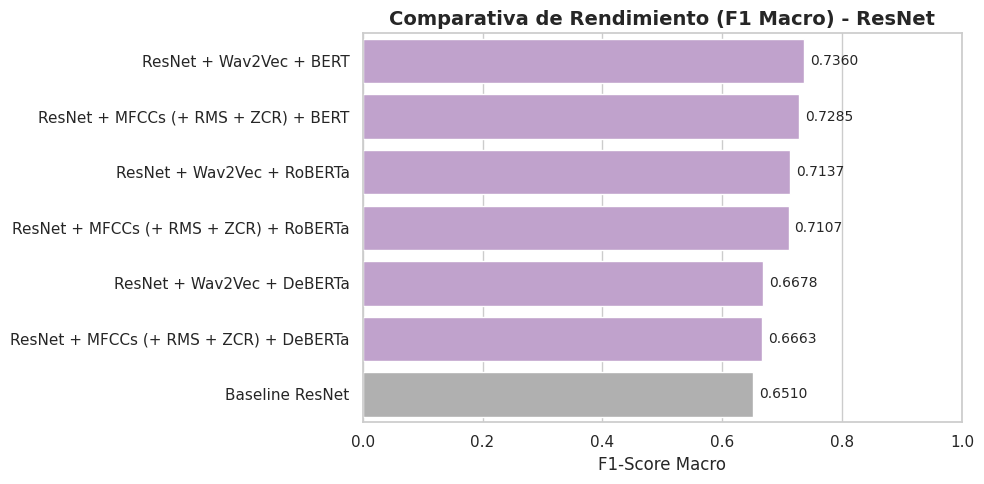

In [44]:
# Indicamos las rutas de los resultados obtenidos para los modelos con ResNet
rutas_resnet = [
    # Baseline Unimodal
    {'Modelo': 'Baseline ResNet', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_resnet.txt'},
    
    # Modelos Multimodales Early Fusion
    {'Modelo': 'ResNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_deberta64.txt'}
]


datos_resnet = []
for item in rutas_resnet:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_resnet.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_resnet = pd.DataFrame(datos_resnet).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_resnet, 'ResNet')

* **EfficientNet**:

RESULTADOS PARA EFFICIENTNET


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
1,EfficientNet + Wav2Vec + BERT,Multimodal,0.7134,0.7853,0.6730
2,EfficientNet + Wav2Vec + RoBERTa,Multimodal,0.7009,0.7959,0.7604
4,EfficientNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.6988,0.7717,0.6103
5,EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.6927,0.7871,0.7167
6,EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6418,0.6983,0.8012
3,EfficientNet + Wav2Vec + DeBERTa,Multimodal,0.6381,0.6890,0.7107
0,Baseline EfficientNet,Unimodal,0.6286,0.6897,0.8201


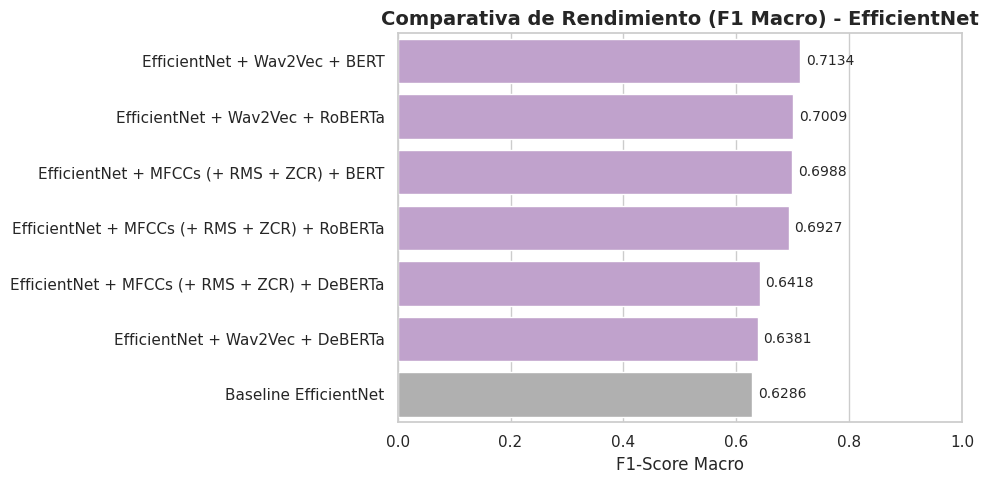

In [45]:
# Indicamos las rutas de los resultados obtenidos para los modelos con EfficientNet
rutas_efficientnet = [
    # Baseline Unimodal
    {'Modelo': 'Baseline EfficientNet', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_efficientnet.txt'},
    
    # Modelos Multimodales Early Fusion
    {'Modelo': 'EfficientNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_deberta64.txt'}
]


datos_efficientnet = []
for item in rutas_efficientnet:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_efficientnet.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_efficientnet = pd.DataFrame(datos_efficientnet).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_efficientnet, 'EfficientNet')

* **ViT**:

RESULTADOS PARA VIT


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
1,ViT + Wav2Vec + BERT,Multimodal,0.7198,0.8023,0.7455
5,ViT + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7127,0.8099,0.7793
4,ViT + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7124,0.7944,0.7565
2,ViT + Wav2Vec + RoBERTa,Multimodal,0.6868,0.7707,0.6859
0,Baseline ViT,Unimodal,0.6485,0.7070,0.8231
3,ViT + Wav2Vec + DeBERTa,Multimodal,0.6346,0.7158,0.8360
6,ViT + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6312,0.7058,0.8141


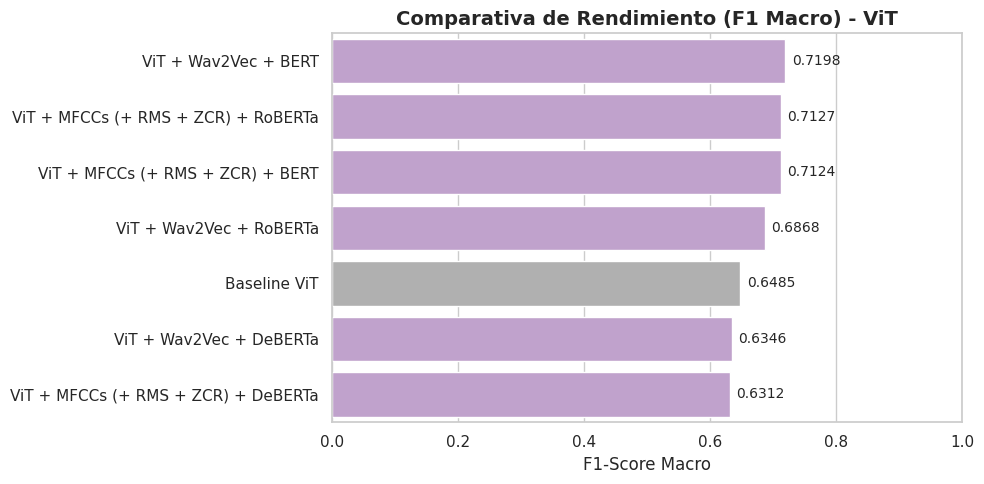

In [46]:
# Indicamos las rutas de los resultados obtenidos para los modelos con ViT
rutas_vit = [
    # Baseline Unimodal
    {'Modelo': 'Baseline ViT', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_VIDEO_vit.txt'},
    
    # Modelos Multimodales Early Fusion
    {'Modelo': 'ViT + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ViT + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ViT + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_bert64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_deberta64.txt'}
]


datos_vit = []
for item in rutas_vit:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_vit.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_vit = pd.DataFrame(datos_vit).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_vit, 'ViT')

* **Wav2Vec**:

RESULTADOS PARA WAV2VEC


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
7,ResNet + Wav2Vec + BERT,Multimodal,0.7360,0.8224,0.8300
1,ViT + Wav2Vec + BERT,Multimodal,0.7198,0.8023,0.7455
8,ResNet + Wav2Vec + RoBERTa,Multimodal,0.7137,0.8018,0.7724
4,EfficientNet + Wav2Vec + BERT,Multimodal,0.7134,0.7853,0.6730
5,EfficientNet + Wav2Vec + RoBERTa,Multimodal,0.7009,0.7959,0.7604
2,ViT + Wav2Vec + RoBERTa,Multimodal,0.6868,0.7707,0.6859
9,ResNet + Wav2Vec + DeBERTa,Multimodal,0.6678,0.7336,0.7992
6,EfficientNet + Wav2Vec + DeBERTa,Multimodal,0.6381,0.6890,0.7107
3,ViT + Wav2Vec + DeBERTa,Multimodal,0.6346,0.7158,0.8360
0,Baseline Wav2Vec,Unimodal,0.4119,0.5470,0.0368


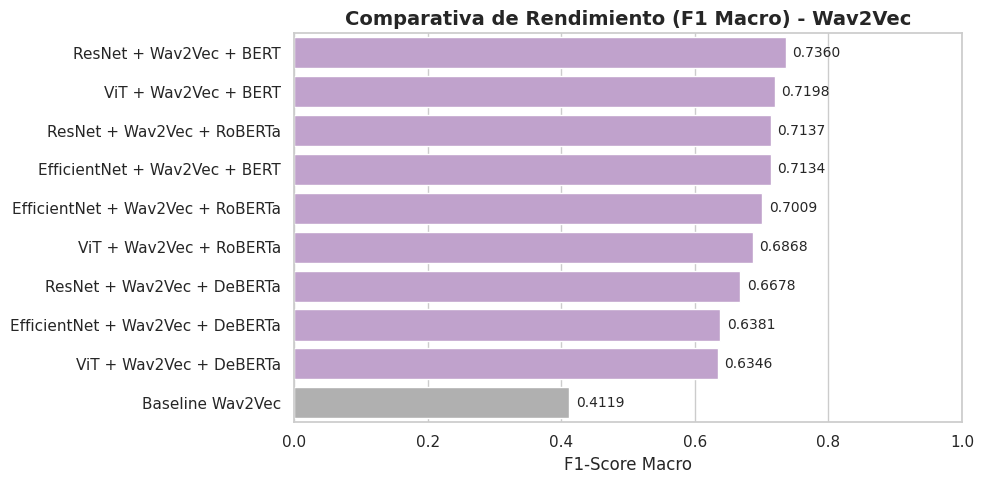

In [47]:
# Indicamos las rutas de los resultados obtenidos para los modelos con Wav2Vec
rutas_wav2vec = [
    # Baseline Unimodal
    {'Modelo': 'Baseline Wav2Vec', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_AUDIO_wav2vec.txt'},
    
    # Modelos Multimodales Early Fusion
    {'Modelo': 'ViT + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ViT + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ViT + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_deberta64.txt'}
]


datos_wav2vec = []
for item in rutas_wav2vec:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_wav2vec.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_wav2vec = pd.DataFrame(datos_wav2vec).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_wav2vec, 'Wav2Vec')

* **MFCCs (+ RMS + ZCR)**:

RESULTADOS PARA MFCC


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
7,ResNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7285,0.8036,0.7346
2,ViT + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7127,0.8099,0.7793
1,ViT + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7124,0.7944,0.7565
8,ResNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7107,0.7981,0.7416
4,EfficientNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.6988,0.7717,0.6103
5,EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.6927,0.7871,0.7167
9,ResNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6663,0.7147,0.7097
6,EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6418,0.6983,0.8012
3,ViT + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6312,0.7058,0.8141
0,Baseline MFCCs (+ RMS + ZCR),Unimodal,0.5497,0.5873,0.5984


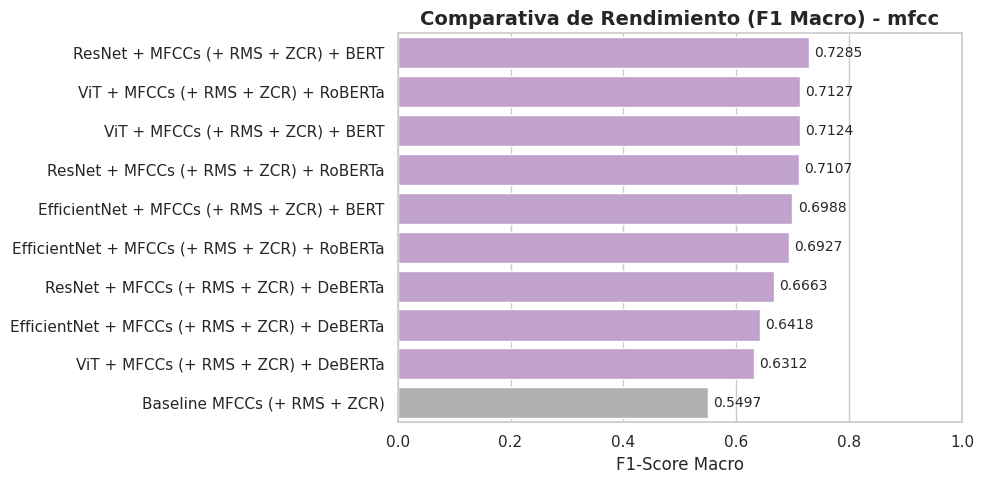

In [48]:
# Indicamos las rutas de los resultados obtenidos para los modelos con MFCCs
rutas_mfcc = [
    # Baseline Unimodal
    {'Modelo': 'Baseline MFCCs (+ RMS + ZCR)', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_AUDIO_mfcc.txt'},
    
    # Modelos Multimodales Early Fusion
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_bert64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_deberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_deberta64.txt'}
]


datos_mfcc = []
for item in rutas_mfcc:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_mfcc.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_mfcc = pd.DataFrame(datos_mfcc).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_mfcc, 'mfcc')

* **BERT**:

RESULTADOS PARA BERT64


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
0,Baseline BERT,Unimodal,0.7424,0.8197,0.6879
1,ResNet + Wav2Vec + BERT,Multimodal,0.7360,0.8224,0.8300
2,ResNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7285,0.8036,0.7346
5,ViT + Wav2Vec + BERT,Multimodal,0.7198,0.8023,0.7455
3,EfficientNet + Wav2Vec + BERT,Multimodal,0.7134,0.7853,0.6730
6,ViT + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.7124,0.7944,0.7565
4,EfficientNet + MFCCs (+ RMS + ZCR) + BERT,Multimodal,0.6988,0.7717,0.6103


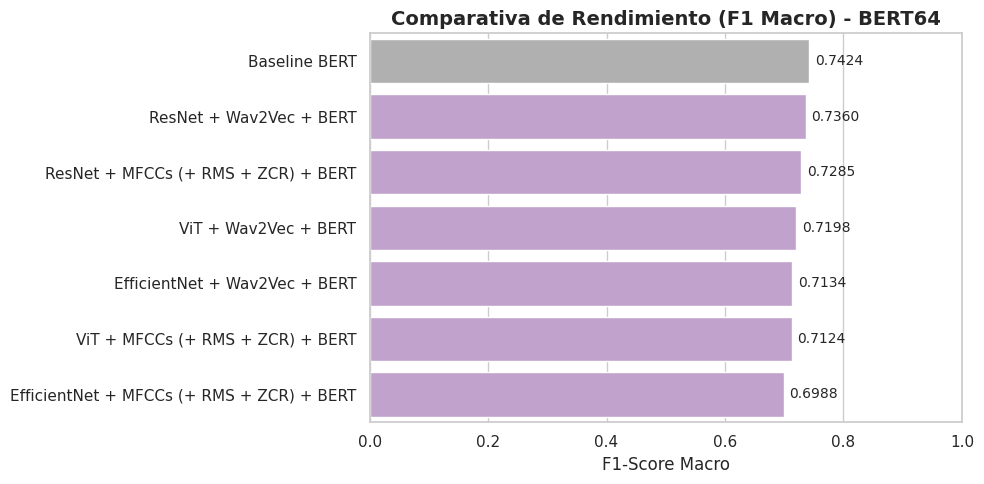

In [49]:
# Indicamos las rutas de los resultados obtenidos para los modelos con BERT
rutas_bert = [
    # Baseline Unimodal
    {'Modelo': 'Baseline BERT', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_bert64.txt'},
    
    # Modelos Multimodales Early Fusion
     {'Modelo': 'ResNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'ViT + Wav2Vec + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + BERT', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_bert64.txt'}
]


datos_bert = []
for item in rutas_bert:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_bert.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_bert = pd.DataFrame(datos_bert).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_bert, 'BERT64')

* **RoBERTa**:

RESULTADOS PARA ROBERTA64


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
0,Baseline RoBERTa,Unimodal,0.7293,0.8070,0.6978
1,ResNet + Wav2Vec + RoBERTa,Multimodal,0.7137,0.8018,0.7724
6,ViT + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7127,0.8099,0.7793
2,ResNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.7107,0.7981,0.7416
3,EfficientNet + Wav2Vec + RoBERTa,Multimodal,0.7009,0.7959,0.7604
4,EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa,Multimodal,0.6927,0.7871,0.7167
5,ViT + Wav2Vec + RoBERTa,Multimodal,0.6868,0.7707,0.6859


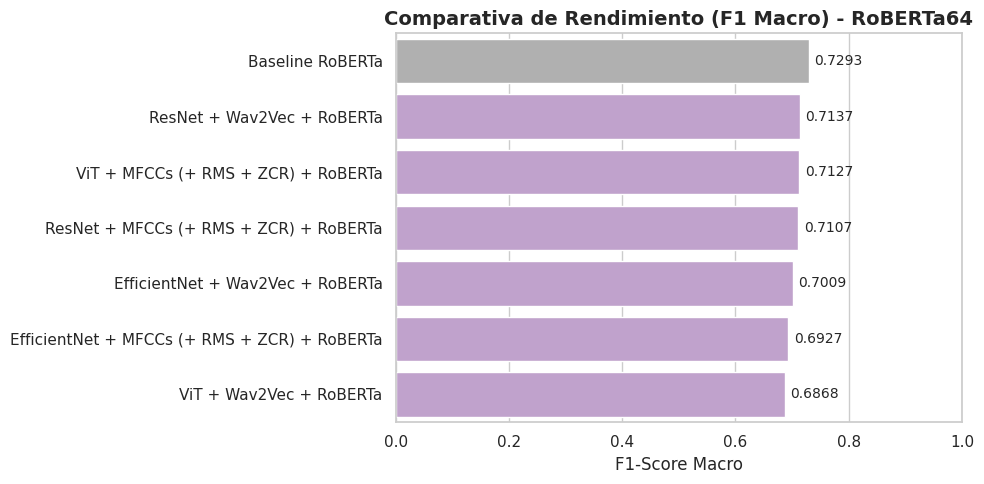

In [50]:
# Indicamos las rutas de los resultados obtenidos para los modelos con RoBERTa
rutas_roberta = [
    # Baseline Unimodal
    {'Modelo': 'Baseline RoBERTa', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_roberta64.txt'},
    
    # Modelos Multimodales Early Fusion
     {'Modelo': 'ResNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ViT + Wav2Vec + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + RoBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_roberta64.txt'}
]


datos_roberta = []
for item in rutas_roberta:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_roberta.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_roberta = pd.DataFrame(datos_roberta).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_roberta, 'RoBERTa64')

* **DeBERTa**:

RESULTADOS PARA DEBERTA64


,Modelo,Modalidad,F1_Macro,AUC,Recall_Estres
1,ResNet + Wav2Vec + DeBERTa,Multimodal,0.6678,0.7336,0.7992
2,ResNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6663,0.7147,0.7097
4,EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6418,0.6983,0.8012
3,EfficientNet + Wav2Vec + DeBERTa,Multimodal,0.6381,0.6890,0.7107
5,ViT + Wav2Vec + DeBERTa,Multimodal,0.6346,0.7158,0.8360
6,ViT + MFCCs (+ RMS + ZCR) + DeBERTa,Multimodal,0.6312,0.7058,0.8141
0,Baseline DeBERTa,Unimodal,0.6077,0.6756,0.6471


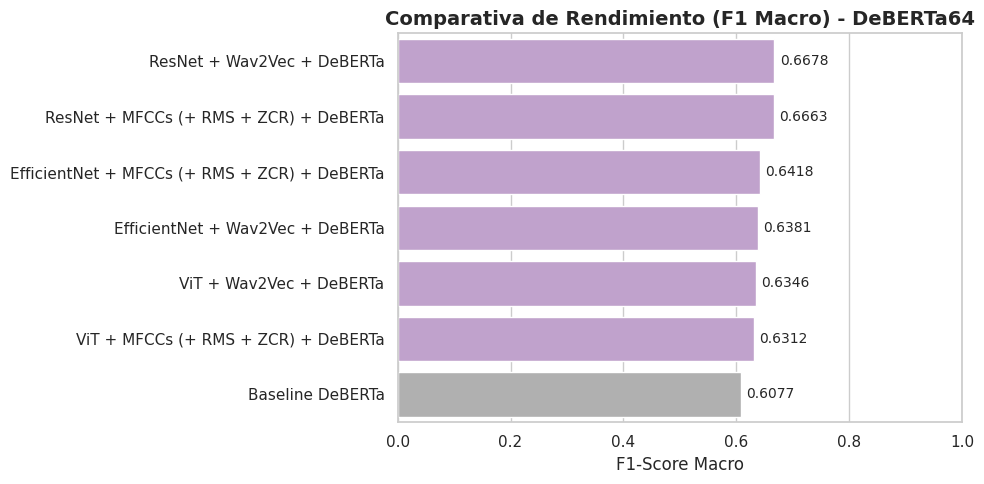

In [52]:
# Indicamos las rutas de los resultados obtenidos para los modelos con DeBERTa
rutas_deberta = [
    # Baseline Unimodal
    {'Modelo': 'Baseline DeBERTa', 'Modalidad': 'Unimodal', 
     'Ruta': 'resultados/resultados_baseline_unimodal/reporte_final_baseline_unimodal_TEXTO_deberta64.txt'},
    
    # Modelos Multimodales Early Fusion
     {'Modelo': 'ResNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ResNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_deberta64.txt'},
    {'Modelo': 'ViT + Wav2Vec + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ViT + MFCCs (+ RMS + ZCR) + DeBERTa', 'Modalidad': 'Multimodal', 
     'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_deberta64.txt'}
]


datos_deberta = []
for item in rutas_deberta:
    f1, auc, recall = extraer_metricas_txt(item['Ruta']) 
    
    datos_deberta.append({
        'Modelo': item['Modelo'], 
        'Modalidad': item['Modalidad'], 
        'F1_Macro': f1, 
        'AUC': auc,
        'Recall_Estres': recall 
    })

# Convertimos a DataFrame y ordenamos por F1 
df_deberta = pd.DataFrame(datos_deberta).sort_values(by='F1_Macro', ascending=False)
plot_comparativa(df_deberta, 'DeBERTa64')

### **3. Elección de los backbones óptimos**

Finalmente, se seleccionan los **codificadores** que consiguen el mayor rendimiento conjunto. Se muestra una tabla global con todos los resultados de los 18 modelos entrenados:

In [53]:
# Definimos las diferentes ventanas que hemos fijado por cada modalidad:
ventana_multimodal = '32f / 11s / 64t'

rutas_multimodales = [
    # --- GRUPO RESNET ---
    {'Modelo': 'ResNet + Wav2Vec + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ResNet + Wav2Vec + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ResNet + MFCCs + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ResNet + MFCCs + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'ResNet + MFCCs + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_resnet32_mfcc11s_deberta64.txt'},

    # --- GRUPO VIT ---
    {'Modelo': 'ViT + Wav2Vec + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'ViT + Wav2Vec + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_bert64.txt'},
    {'Modelo': 'ViT + Wav2Vec + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'ViT + MFCCs + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_roberta64.txt'},
    {'Modelo': 'ViT + MFCCs + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_bert64.txt'},
    {'Modelo': 'ViT + MFCCs + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_vit32_mfcc11s_deberta64.txt'},

    # --- GRUPO EFFICIENTNET ---
    {'Modelo': 'EfficientNet + Wav2Vec + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_bert64.txt'},
    {'Modelo': 'EfficientNet + Wav2Vec + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_wav2vec11s_deberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs + RoBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_roberta64.txt'},
    {'Modelo': 'EfficientNet + MFCCs + BERT', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_bert64.txt'},
    {'Modelo': 'EfficientNet + MFCCs + DeBERTa', 'Ruta': 'reporte_final_global_dev_modelo_early_efficientnet32_mfcc11s_deberta64.txt'}
]

datos_multi = []
for item in rutas_multimodales:
    f1, auc, recall = extraer_metricas_txt(item['Ruta'])
    datos_multi.append({
        'Arquitectura Multimodal': item['Modelo'],
        'Ventana': ventana_multimodal,
        'F1_Macro': f1,
        'AUC': auc,
        'Recall_Estres': recall
    })

# Creamos el DataFrame y lo ordenamos de mejor a peor según F1 Macro
df_multi = pd.DataFrame(datos_multi).sort_values(by='F1_Macro', ascending=False)

# Guardamos a CSV 
df_multi.to_csv("tabla_multimodales_seleccion_early.csv", index=False)

# Mostramos en pantalla
print("TABLA: COMBINACIONES MULTIMODALES (EARLY FUSION)")
display(df_multi.style.background_gradient(subset=['F1_Macro', 'AUC', 'Recall_Estres'], cmap='Blues').format(precision=4))

TABLA: COMBINACIONES MULTIMODALES (EARLY FUSION)


,Arquitectura Multimodal,Ventana,F1_Macro,AUC,Recall_Estres
1,ResNet + Wav2Vec + BERT,32f / 11s / 64t,0.7360,0.8224,0.8300
4,ResNet + MFCCs + BERT,32f / 11s / 64t,0.7285,0.8036,0.7346
7,ViT + Wav2Vec + BERT,32f / 11s / 64t,0.7198,0.8023,0.7455
0,ResNet + Wav2Vec + RoBERTa,32f / 11s / 64t,0.7137,0.8018,0.7724
13,EfficientNet + Wav2Vec + BERT,32f / 11s / 64t,0.7134,0.7853,0.6730
9,ViT + MFCCs + RoBERTa,32f / 11s / 64t,0.7127,0.8099,0.7793
10,ViT + MFCCs + BERT,32f / 11s / 64t,0.7124,0.7944,0.7565
3,ResNet + MFCCs + RoBERTa,32f / 11s / 64t,0.7107,0.7981,0.7416
12,EfficientNet + Wav2Vec + RoBERTa,32f / 11s / 64t,0.7009,0.7959,0.7604
16,EfficientNet + MFCCs + BERT,32f / 11s / 64t,0.6988,0.7717,0.6103
